순간마다 target과 current vertor의 외적을 계산해서, 가장 가까운 rotation축을 우선 선택하는 코드

In [57]:
from math import *
import numpy as np
from scipy.linalg import expm
from qutip import *
import random
from scipy import optimize
from datetime import datetime
import time
import pandas as pd
from scipy.linalg import fractional_matrix_power
from sklearn.feature_extraction.text import CountVectorizer
from scipy import linalg
from qutip import bloch
import matplotlib.pyplot as plt

In [58]:
# complex number
j = (-1)**0.5
 

# pauli matrix
sx = np.array([[0, 1], [1, 0]])
sy = np.array([[0, -j], [j, 0]])
sz = np.array([[1, 0], [0, -1]])
s0 = np.array([[1, 0], [0, 1]])

# Detunning Factor
d0 = 0.15
v0 = 0.02

In [59]:
def Rx(theta):
    return np.matrix([[cos(theta/2),     -1j*sin(theta/2)],
                    [-1j*sin(theta/2),     cos(theta/2)]])

def Rz(phi): # Rz는 사용하지 않음. 해밀토니안에 의한 회전으로만 컨트롤
    return np.matrix([[cos(phi/2)-1j*sin(phi/2),       0],
                     [0,                          cos(phi/2)+1j*sin(phi/2)]])

In [60]:
def unitary(dt, choice) :
    choice_list = [0,1,-1,1,-1] # x,y-rotiation 방향 선택
    if choice <3 :
        Ham = (d0*sz+v0*choice_list[choice]*sx)
    else :
        Ham = (d0*sz+v0*choice_list[choice]*sy)
    eigvals = np.linalg.eigh(Ham)[0]
    eigvecs = 1*np.linalg.eigh(Ham)[1]
    E = np.diag(eigvals)
    U_H = eigvecs.conj().T
    U_e = U_H.conj().T @ expm(-j*E*dt) @ U_H
    return U_e

In [61]:
# axis=[]
# def rotation_axis() :
#     choice_list = [0,1,-1,1,-1] # x,y-rotiation 방향 선택
#     c = 0
#     for i in choice_list :
#         if c <3 :
#             Ham = (d0*sz+v0*choice_list[i]*sx)
#         else :
#             Ham = (d0*sz+v0*choice_list[i]*sy)
#         # print(i+1,Ham,"\n")
#         rot_vec = ([[np.trace(sx*Ham).real],
#                    [np.trace(sy*Ham).real],
#                    [np.trace(sz*Ham).real]])
#         # print(f"{sx*Ham}\n{sy*Ham}\n{sz*Ham}\n\n")
#         axis.append(rot_vec)
#         c+=1
#     return 0    

In [62]:
norm = (d0**2+v0**2)**0.5
choice_0 = np.array([0,0,1])
choice_1 = np.array([v0/norm,0,d0/norm])
choice_2 = np.array([-v0/norm,0,d0/norm])
choice_3 = np.array([0,v0/norm,d0/norm])
choice_4 = np.array([0,-v0/norm,d0/norm])
rot_vec = [choice_0,choice_1,choice_2,choice_3,choice_4]

In [63]:
def state_fidelity(rho_1, rho_2): #fidelity
        if np.shape(rho_1) != np.shape(rho_2):
            print("Dimensions of two states do not match.")
            return 0
        else:
            sqrt_rho_1 = fractional_matrix_power(rho_1, 1 / 2)
            fidelity = np.trace(fractional_matrix_power(sqrt_rho_1 @ rho_2 @ sqrt_rho_1, 1 / 2)) ** 2
            return np.real(fidelity)

In [64]:
init_wave = np.array([[1],[0]])
irho_init = np.kron(init_wave,init_wave.conj().T)

In [65]:
target_theta, target_phi, dtl, combi =	0.942477796,	3.490658504,	[2.74545303],	[2, 2, 2, 2, 2, 1, 2, 1, 2, 2, 2, 2, 2, 1, 2, 1, 2, 2, 2, 2, 2, 1, 2, 1, 2, 2]
dt = dtl[0]
target_U = Rz(target_phi) @ Rx(target_theta)
irho_target = target_U @ irho_init @target_U.conj().T

In [66]:
point_list = []
def make_combination(irho_target,irho_init,dt) :
    cost = 1
    F=1
    combination = []
    irho_current = irho_init
    vec_t = np.array([np.trace(irho_target*sx).real, np.trace(irho_target*sy).real,np.trace(irho_target*sz).real])
    iter = 0
    while (F>0.01) and (iter<10000):
        vec_c = np.array([np.trace(irho_current*sx).real,np.trace(irho_current*sy).real,np.trace(irho_current*sz).real])
        cross = np.cross(vec_c,vec_t)
        inner = 0
        choice = -1
        for i in range(1,5):
            temp_inner = (np.inner(rot_vec[i],cross))
            # print(i, temp_inner)
            if temp_inner > inner :
                inner = temp_inner
                choice = i
                #print("True")
            #print("!!!!!!",inner,choice)
        instant_unitary = unitary(dt, choice)
        irho_current = instant_unitary @ irho_current @ instant_unitary.conj().T
        F = 1 - state_fidelity(irho_target,irho_current)
        combination.append(choice)
        iter+=1  
    if cost > F :
        cost = F
        combi = combination.copy()
    return cost, combi

In [67]:
k=50
combination = []
for i in combi :
    combination += [i for j in range(k)]
# for i in combi :
#     for j in range(k):
#         combination_temp.append(i)


# temp = combi.copy()
# for k in range(len(temp)) :
#     for j in range(10):
#         combination.append(temp[k])
#temp = np.vstack([combi, combi, combi, combi, combi, combi, combi, combi, combi, combi, combi])


#print(type(temp))
print(combination)

dt = dt/k

[2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 

In [68]:
print(f"{len(combination)}\n{combination}")

1300
[2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2

[-1.8089613286011313e-05, 0.002196261328864481, 0.9999975880515614]
[-7.235345736998362e-05, 0.004391916120419083, 0.9999903528723496]
[-0.00016277654630940554, 0.006586358004860183, 0.9999782964604906]
[-0.0002893339081319551, 0.00877898094735041, 0.9999614221455804]
[-0.0004519905917319619, 0.010969179415386124, 0.9999397345877665]
[-0.0006507016765227874, 0.013156348546026177, 0.9999132397764606]
[-0.0008854122848424576, 0.015339884312935774, 0.9998819450286842]
[-0.0011560575971091228, 0.01751918369319925, 0.9998458589870481]
[-0.0014625628697221577, 0.019693644833855786, 0.9998049916173659]
[-0.00180484345570396, 0.02186266721811197, 0.9997593542059012]
[-0.0021828048280767443, 0.024025651831185407, 0.999708959356251]
[-0.002596342605967877, 0.02618200132573347, 0.9996538209858651]
[-0.003045342583436547, 0.028331120186821573, 0.9995939543222021]
[-0.0035296807610137966, 0.03047241489638542, 0.9995293758985246]
[-0.004049223379947222, 0.03260529409714173, 0.9994601035493329]
[-0.0

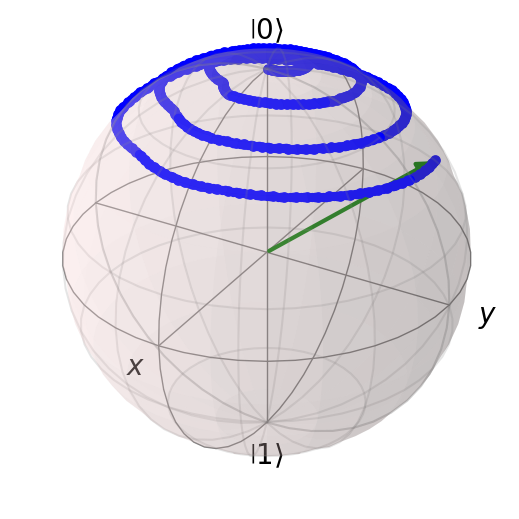

In [69]:
b = Bloch()
irho_mid = np.matrix(irho_init)
#irho_mid = (irho_init)
# b.add_points([0,0,1],'m')
#combination= [1] * 10
# dt = 10
point_list =[]
for i in combination:
    instant_U = unitary(dt,i)
    #print((instant_U @ instant_U.conj().T))
    #print(instant_U)
    irho_mid = (instant_U @ irho_mid @ instant_U.conj().T)
    point = [np.trace(irho_mid*sx).real,
             np.trace(irho_mid*sy).real,
             np.trace(irho_mid*sz).real]
    b.add_points(point,'m')
    print(point)
    point_list.append(point)
vector = np.array([np.trace(irho_target*sx).real,
             np.trace(irho_target*sy).real,
             np.trace(irho_target*sz).real])
b.add_vectors(vector)
# irho_mid = np.array(irho_mid)
# print(1 - state_fidelity(irho_target,irho_mid))
# point = [np.trace(irho_target*sx).real,
#          np.trace(irho_target*sy).real,
#          np.trace(irho_target*sz).real]
# print(type(irho_target),"\n",point)
# b.add_points(point,'g')
b.point_marker = ['o']
b.show()

In [70]:
# fin1 = pd.DataFrame(point_list)

# fin1.rename(columns={0:"x",1:"y",2:"z"},inplace=True)
# fin1.to_csv("/Users/qwon/Documents/DataSetForNVSpin/find_rotationaxe_2.csv",index = False)

In [71]:
pi

3.141592653589793